In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

### Raw data

In [2]:
def extract_particle_sequences(h5_file_path, gr_key="perturbative"): # sort_by_E==True
    """
    Extracts the full sequence of particles for each event, flattened as a list of tokens. 
    Sort by time_step, then by E (descending) within each time step.
    Each token: [time_step, gibuuID, charge, x, y, z, E, Px, Py, Pz]
    Returns: List of lists (one per event), each inner list is the sequence of tokens.
    """
    sequences_per_event = []

    with h5py.File(h5_file_path, 'r') as f:
        events = f[gr_key]

        for i in range(len(events)):
            event_data = events[i]
            if len(event_data) == 0:
                sequences_per_event.append([])
                continue

            # Find all unique time steps, sorted
            time_steps = np.unique(event_data['time_step'])
            sequence = []
            for t in time_steps:
                mask = event_data['time_step'] == t
                particles = event_data[mask]
                # Sort by E descending
                sorted_idx = np.argsort(-particles['E'])
                particles = particles[sorted_idx]
                for p in particles:
                    token = [
                        int(p['time_step']),
                        int(p['gibuuID']),
                        int(p['charge']),
                        float(p['x']),
                        float(p['y']),
                        float(p['z']),
                        float(p['E']),
                        float(p['Px']),
                        float(p['Py']),
                        float(p['Pz']),
                    ]
                    if int(p['time_step']) > 1: # do not include time_step#1 as it seems always the same with time_step#2 (TB confirmed with GiBUU experts)
                        # TB considered, only include particles whose position is within the range of argon nucleus (r ≈ 4 fm)
                        sequence.append(token)
            
            sequences_per_event.append(sequence)
    return sequences_per_event

data = extract_particle_sequences("GiBUU_FSI_particles.h5")

Maximum sequence length: 5366
Minimum sequence length: 151
Average sequence length: 774.7
Sequence length for evt0: 833
[2, 1, 0, 2.0931642055511475, -2.705719470977783, 0.2997022867202759, 2.0826897621154785, -0.6660433411598206, 1.0246180295944214, 1.400406002998352]
[2, 1, 1, 2.0931642055511475, -2.705719470977783, 0.2997022867202759, 1.0682777166366577, -0.05910364165902138, -0.32833585143089294, 0.4430660903453827]
[3, 1, 0, 2.028975248336792, -2.6069424152374268, 0.4348379969596863, 2.0826611518859863, -0.6643854379653931, 1.0225567817687988, 1.4006779193878174]
[3, 1, 1, 2.0810835361480713, -2.77243971824646, 0.3898245096206665, 1.0683176517486572, -0.059716880321502686, -0.32756975293159485, 0.4429897367954254]
[4, 1, 0, 1.9648871421813965, -2.5082874298095703, 0.5701416730880737, 2.0826499462127686, -0.6626641154289246, 1.0203351974487305, 1.401181936264038]


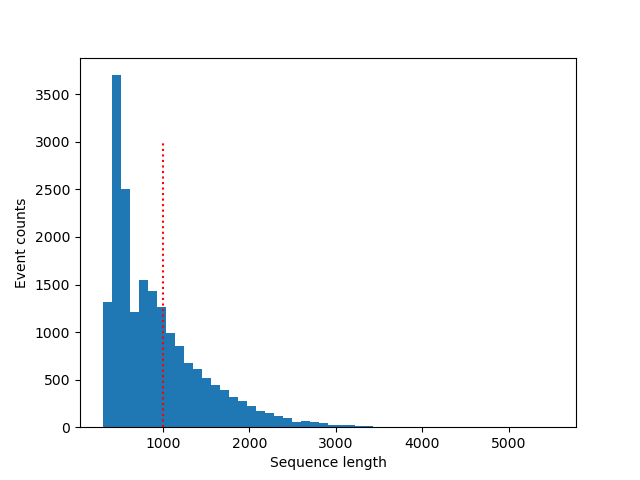

In [129]:
max_length = max(len(sequence) for sequence in data)
print(f"Maximum sequence length: {max_length}")
min_length = min(len(sequence) for sequence in data)
print(f"Minimum sequence length: {min_length}")
avg_length = sum(len(sequence) for sequence in data) / len(data)
print(f"Average sequence length: {avg_length:.1f}")

ievt = 0
# [ts, gibuuID, chg, x, y, z, E, Px, Py, Pz]
print(f"Sequence length for evt{ievt}: {len(data[ievt])}", *data[ievt][0:5], sep='\n')

plt.figure()
plt.hist([len(sequence)+151 for sequence in data], bins=50)
plt.plot([1000, 1000], [0, 3000], "r:")
plt.xlabel("Sequence length")
plt.ylabel("Event counts")
plt.show()

### Model definition

In [4]:
EOS_STEP_TOKEN = 0x400  # 0b10000000000 (1024)
EOS_TOKEN = 0x7ff       # 0b11111111111 (2047)
PAD_TOKEN = 0
def encode_id(gibuu_id, charge, is_real=0):
    """
    Encode particle class to a 12-bit ID
     --------------------------------
    |   11    | 10 9 8 7 | 6 5 ... 0 | : bit
     --------------------------------
    | is_real |   Q + 8  | GiBUU ID  | : content
     --------------------------------
    """
    bits = gibuu_id \
        + ((charge+8) << 7) \
        + is_real * (1 << 11)

    return bits

def decode_id(bits):
    """
    Decode particle class from a 12-bit ID
    """
    gibuu_id = bits & 0x7f
    charge = ((bits >> 7) & 0xf) - 8
    is_real = (bits >> 11) & 0x1

    return gibuu_id, charge, is_real


import torch
import torch.nn.functional as F
from torch import nn

def get_mlp( # return an MLP with fully connected layers
    in_features, hidden_features, hidden_layers, out_features,
    Activation=nn.ReLU, bias=True
):
    
    dims = [in_features] + [hidden_features]*hidden_layers + [out_features]
    actn = Activation()

    net = []
    for i in range(len(dims)-1):
        net.append(nn.Linear(dims[i], dims[i+1], bias=bias))
        if i < len(dims) - 2:
            net.append(actn)
    return nn.Sequential(*net)

class ParticleEncoder(nn.Module): # encoded particle ID -> dense vector embedding
    def __init__(self, cfg):
        super().__init__()
        
        self.embedding = nn.Embedding(**cfg['embedding'])
        self.encoder = get_mlp(**cfg['particle_encoder'])

    def forward(self, encoded_ids, feats):
        '''
        The embedding captures categorical identity (particle type)
        The MLP encodes continuous features (kinematics)
        '''
        x_out = self.embedding(encoded_ids) + self.encoder(feats)
        return x_out # (batch_size, seq_len, embedding_dim)

class ParticleDecoder(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        
        dec_cfg = cfg['particle_decoder'].copy()
        num_classes = dec_cfg.pop('num_classes')

        # for backward compatibility, simply use linear prediction
        dec_cfg.setdefault('hidden_features', 0)
        dec_cfg.setdefault('hidden_layers', 0)
        
        self.part_type_cls = nn.Linear(dec_cfg['in_features'], num_classes)
        self.part_feat_dec = get_mlp(**dec_cfg)
    
    def forward(self, x):
        part_type = self.part_type_cls(x)
        part_feat = self.part_feat_dec(x)
        return part_type, part_feat

In [5]:
class GiBUUTransformer(nn.Module):
    '''
    GPT-style Transformer for GiBUU particle sequence generation.
    Input: [encoded_id, x, y, z, E, Px, Py, Pz]
    Autoregressive model that generates particles one by one.
    '''
    def __init__(self, cfg):
        super().__init__()
        
        # Particle Encoder + Decoder
        self.particle_encoder = ParticleEncoder(cfg)
        self.particle_decoder = ParticleDecoder(cfg)

        # Transformer Decoder (GPT-style, no encoder)
        layer_cfg = cfg['transformer']['layer']
        decoder_layer = nn.TransformerDecoderLayer(**layer_cfg)
        
        d_model = layer_cfg['d_model']
        decoder_norm = nn.LayerNorm(d_model)
        
        self.decoder = nn.TransformerDecoder(
            decoder_layer, norm=decoder_norm,
            **cfg['transformer']['decoder']
        )

    def create_causal_mask(self, seq_len, device=None):
        """
        Create causal mask that only allows attention to previous positions.
        
        Parameters:
        -----------
        seq_len: int
            Length of the sequence
        device: torch.device, optional
            Device to place the mask on
            
        Returns:
        --------
        mask: tensor
            Boolean mask of shape (seq_len, seq_len) where True means masked
        """
        mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
        if device is not None:
            mask = mask.to(device)
        return mask

    def forward(
        self, encoded_ids, particle_feats, 
        padding_mask=None, causal_mask=None, return_aux=False
    ):
        '''
        Forward pass through the GPT-style Transformer.
        
        Parameters:
        -----------
        encoded_ids: tensor
            Encoded particle IDs of shape (batch, seq_len).
        particle_feats: tensor
            Particle features of shape (batch, seq_len, 7) - [x, y, z, E, Px, Py, Pz].
        padding_mask: tensor, optional
            Boolean padding mask of shape (batch, seq_len).
        causal_mask: tensor, optional
            Causal mask for autoregressive attention of shape (seq_len, seq_len).
            If None, will be created automatically.
        return_aux: bool, optional
            Return auxiliary outputs from intermediate layers.
            
        Returns:
        --------
        output: dict
            Dictionary containing:
            - 'embeddings': Final embeddings (batch, seq_len, d_model)
            - 'particle_types': Logits for particle type prediction
            - 'particle_feats': Decoded particle features
            - 'aux_outputs': Auxiliary outputs (if return_aux=True)
        '''
        # Encode particles
        embeddings = self.particle_encoder(encoded_ids, particle_feats)
        
        # Create dummy memory for decoder (since we're not using encoder)
        # In GPT-style, the decoder attends to its own input
        memory = embeddings
        
        # Create causal mask if not provided
        if causal_mask is None:
            seq_len = encoded_ids.shape[1]
            causal_mask = self.create_causal_mask(seq_len, device=encoded_ids.device)
        
        if return_aux:
            # Get auxiliary outputs from intermediate layers
            aux_outputs = self.decode_with_aux(embeddings, memory, padding_mask, causal_mask)
            embeddings = aux_outputs[-1]  # Final layer output
            output = {
                'embeddings': embeddings,
                'aux_outputs': aux_outputs[:-1]  # All but last
            }
        else:
            # Standard forward pass
            embeddings = self.decoder(
                embeddings, memory,
                tgt_key_padding_mask=padding_mask,
                tgt_mask=causal_mask
            )
            output = {'embeddings': embeddings}
        
        # Decode to particle types and features
        particle_types, particle_feats = self.particle_decoder(embeddings)
        output.update({
            'particle_types': particle_types,
            'particle_feats': particle_feats
        })
        
        return output

    def decode_with_aux(self, embeddings, memory, padding_mask=None, causal_mask=None):
        '''
        Decoder forward pass with auxiliary outputs from intermediate layers.
        '''
        x = embeddings
        aux_outputs = []

        # Create causal mask if not provided
        if causal_mask is None:
            causal_mask = self.create_causal_mask(encoded_ids.shape[1], device=encoded_ids.device)
        
        for layer in self.decoder.layers:
            x = layer(
                x, memory,
                tgt_key_padding_mask=padding_mask,
                tgt_mask=causal_mask
            )
            aux_outputs.append(x)
        
        return aux_outputs

In [6]:
import torch
import torch.nn.functional as F

def particle_gpt_loss(output, batch):
    """
    GPT-style loss for particle sequence generation.
    Each position predicts the next token based on all previous tokens.
    
    Parameters:
    -----------
    output: dict
        Model output with 'particle_types' and 'particle_feats'
    batch: dict
        Contains 'encoded_ids', 'particle_feats', 'padding_mask'
        
    Returns:
    --------
    loss: dict
        Dictionary with 'total_loss', 'type_loss', 'feat_loss'
    """
    particle_types = output['particle_types']  # (batch, seq_len, num_classes)
    particle_feats = output['particle_feats']  # (batch, seq_len, 7)
    
    # Targets (shifted by 1 for next token prediction)
    targets_types = batch['encoded_ids']  # (batch, seq_len)
    targets_feats = batch['particle_feats']  # (batch, seq_len, 7)
    
    # Create shifted targets (next token prediction)
    # Input:  [token1, token2, token3, token4]
    # Target: [token2, token3, token4, token5]
    targets_types_shifted = targets_types[:, 1:]  # (batch, seq_len-1)
    targets_feats_shifted = targets_feats[:, 1:]  # (batch, seq_len-1)
    
    # Shift predictions to match targets
    particle_types_shifted = particle_types[:, :-1]  # (batch, seq_len-1, num_classes)
    particle_feats_shifted = particle_feats[:, :-1]  # (batch, seq_len-1, 7)
    
    # Type loss (cross-entropy)
    type_loss = F.cross_entropy(
        particle_types_shifted.reshape(-1, particle_types_shifted.size(-1)),
        targets_types_shifted.reshape(-1),
        reduction='none'
    )
    
    # Feature loss (MSE)
    feat_loss = F.mse_loss(
        particle_feats_shifted.reshape(-1, 7),
        targets_feats_shifted.reshape(-1, 7),
        reduction='none'
    ).mean(dim=1)
    
    # Apply padding mask (exclude padding positions from loss)
    padding_mask = batch['padding_mask']
    if padding_mask is not None:
        # Shift padding mask to match shifted targets
        padding_mask_shifted = padding_mask[:, 1:]  # (batch, seq_len-1)
        padding_mask_flat = padding_mask_shifted.reshape(-1)  # FIXED: use .reshape()
        
        # Zero out padding positions
        type_loss = type_loss * (~padding_mask_flat).float()
        feat_loss = feat_loss * (~padding_mask_flat).float()
        
        # Average over valid positions
        num_valid = (~padding_mask_flat).sum()
        type_loss = type_loss.sum() / max(num_valid, 1)
        feat_loss = feat_loss.sum() / max(num_valid, 1)
    else:
        type_loss = type_loss.mean()
        feat_loss = feat_loss.mean()
    
    # Combine losses with weights
    total_loss = type_loss + feat_loss
    
    return {
        'total_loss': total_loss,
        'type_loss': type_loss,
        'feat_loss': feat_loss
    }

In [7]:
import lightning.pytorch as pl

class GiBUUSeqOfSetsModel(pl.LightningModule):
    """
    Lightning module for GiBUU particle sequence generation using GPT-style autoregressive training.
    """
    def __init__(self, cfg):
        super().__init__()
        
        # Model
        self.net = GiBUUTransformer(cfg['model'])
        
        # Loss weights
        self.type_loss_weight = cfg.get('type_loss_weight', 1.0)
        self.feat_loss_weight = cfg.get('feat_loss_weight', 1.0)
        
        # Training config
        self.lr = cfg.get('lr', 1e-4)
        self.weight_decay = cfg.get('weight_decay', 1e-5)
        
        self.save_hyperparameters()

    def forward(self, encoded_ids, particle_feats, padding_mask=None):
        """
        Forward pass through the model.
        
        Parameters:
        -----------
        encoded_ids: tensor (batch, seq_len)
            Encoded particle IDs
        particle_feats: tensor (batch, seq_len, 7)
            Particle features [x, y, z, E, Px, Py, Pz]
        padding_mask: tensor (batch, seq_len), optional
            Boolean padding mask
            
        Returns:
        --------
        output: dict
            Model output with 'particle_types' and 'particle_feats'
        """
        return self.net(encoded_ids, particle_feats, padding_mask)

    def training_step(self, batch, batch_idx):
        """
        Training step.
        """
        # Forward pass
        output = self(
            batch['encoded_ids'], 
            batch['particle_feats'], 
            batch['padding_mask']
        )
        
        # Compute loss
        loss_dict = particle_gpt_loss(output, batch)
        
        # Log losses
        self.log('train_loss', loss_dict['total_loss'], prog_bar=True)
        self.log('train_type_loss', loss_dict['type_loss'])
        self.log('train_feat_loss', loss_dict['feat_loss'])
        
        return loss_dict['total_loss']

    def validation_step(self, batch, batch_idx):
        """
        Validation step.
        """
        # Forward pass
        output = self(
            batch['encoded_ids'], 
            batch['particle_feats'], 
            batch['padding_mask']
        )
        
        # Compute loss
        loss_dict = particle_gpt_loss(output, batch)
        
        # Log losses
        self.log('val_loss', loss_dict['total_loss'], prog_bar=True)
        self.log('val_type_loss', loss_dict['type_loss'])
        self.log('val_feat_loss', loss_dict['feat_loss'])
        
        return loss_dict['total_loss']

    def configure_optimizers(self):
        """
        Configure optimizer and learning rate scheduler.
        """
        optimizer = torch.optim.AdamW(
            self.parameters(), 
            lr=self.lr, 
            weight_decay=self.weight_decay
        )
        
        # Optional: Add learning rate scheduler
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, 
            T_max=100,  # Adjust based on your training epochs
            eta_min=1e-6
        )
        
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }


### Data Loader

In [8]:
def prepare_sequence_for_training(raw_sequences, max_seq_len=6000, EOS_STEP_TOKEN=EOS_STEP_TOKEN, EOS_TOKEN=EOS_TOKEN, PAD_TOKEN=PAD_TOKEN, recursive_truncate=False):
    """
    Prepare raw particle sequences for training:
    - Encode particle IDs using encode_id()
    - Insert EOS_STEP_TOKEN after each time step
    - Insert EOS_TOKEN at the end
    - Pad to max length
    - Remove time_step (not needed in model input)
    
    Parameters:
    -----------
    raw_sequences: List of lists
        Each inner list is a sequence of particle tokens: [ts, gibuuID, chg, x, y, z, E, Px, Py, Pz]
    max_seq_len: int
        Maximum sequence length after padding
    EOS_STEP_TOKEN: int
        Token for end of time step
    EOS_TOKEN: int
        Token for end of sequence
    PAD_TOKEN: int
        Token for padding
    recursive_truncate: bool
        If True, create additional sequences from truncated sequences (only affect sequences longer than max_seq_len)
        
    Returns:
    --------
    encoded_ids: tensor (batch, seq_len)
    particle_feats: tensor (batch, seq_len, num_features)
    padding_mask: tensor (batch, seq_len)
    """
    print(f"### Start prepare_sequence_for_training: {len(raw_sequences)} raw event sequences")
    processed_sequences = []

    i_seq = 1
    for sequence in raw_sequences:
        if len(sequence) == 0:
            # Empty event: just EOS token
            processed_seq = [[EOS_TOKEN, 0, 0, 0, 0, 0, 0, 0]]
        else:
            processed_seq = []
            current_time_step = None
            
            for token in sequence:
                ts, gibuu_id, charge, x, y, z, E, Px, Py, Pz = token
                
                # Check if we've moved to a new time step
                if current_time_step is not None and ts != current_time_step:
                    # Insert EOS_STEP_TOKEN after the previous time step
                    processed_seq.append([EOS_STEP_TOKEN, 0, 0, 0, 0, 0, 0, 0])
                
                current_time_step = ts
                
                # Encode particle ID
                encoded_id = encode_id(gibuu_id, charge)
                
                # Create token: [encoded_id, x, y, z, E, Px, Py, Pz]
                processed_token = [encoded_id, x, y, z, E, Px, Py, Pz]
                processed_seq.append(processed_token)
            
            # Insert EOS_STEP_TOKEN after the last time step
            if len(processed_seq) > 0:
                processed_seq.append([EOS_STEP_TOKEN, 0, 0, 0, 0, 0, 0, 0])
            
            # Insert EOS_TOKEN at the end
            processed_seq.append([EOS_TOKEN, 0, 0, 0, 0, 0, 0, 0])

        if not recursive_truncate:
            # Pad to max length
            if len(processed_seq) < max_seq_len:
                pad_length = max_seq_len - len(processed_seq)
                padding = [[PAD_TOKEN, 0, 0, 0, 0, 0, 0, 0]] * pad_length
                processed_seq.extend(padding)
            else:
                processed_seq = processed_seq[:max_seq_len]
                
            processed_sequences.append(processed_seq)
        else:
            complete_recursive_truncate = False
            while not complete_recursive_truncate:
                if len(processed_seq) <= max_seq_len:
                    pad_length = max_seq_len - len(processed_seq)
                    padding = [[PAD_TOKEN, 0, 0, 0, 0, 0, 0, 0]] * pad_length
                    processed_seq.extend(padding)
                    processed_sequences.append(processed_seq)
                    complete_recursive_truncate = True
                else:
                    # truncate the sequence at max_seq_len
                    append_seq = processed_seq[:max_seq_len]
                    processed_sequences.append(append_seq)
                    # start the remaining sequence from the last complete time step (right after the penultimate EOS_STEP_TOKEN)
                    indices = [i for i, token in enumerate(append_seq) if token[0] == EOS_STEP_TOKEN]
                    if len(indices) < 2:
                        raise Exception("The step may be as long as max_seq_len. Increase max_seq_len if it's too small. Otherwise, there may be other bug.")
                    start_idx = indices[-2]
                    processed_seq = processed_seq[start_idx+1:]
        
        if i_seq%10000 == 0:
            print(f"Done loading {i_seq}/{len(raw_sequences)} raw event sequences...")
        i_seq += 1

    print("Converting to tensors...")
    batch_size = len(processed_sequences)
    seq_len = len(processed_sequences[0])
    
    # Extract encoded IDs and features
    encoded_ids = []
    particle_feats = []
    
    for seq in processed_sequences:
        seq_ids = []
        seq_feats = []
        for token in seq:
            encoded_id = token[0]
            features = token[1:]  # x, y, z, E, Px, Py, Pz
            
            seq_ids.append(encoded_id)
            seq_feats.append(features)
        
        encoded_ids.append(seq_ids)
        particle_feats.append(seq_feats)
    
    # Convert to tensors
    encoded_ids = torch.tensor(encoded_ids, dtype=torch.long)
    particle_feats = torch.tensor(particle_feats, dtype=torch.float32)
    
    # Create padding mask
    padding_mask = (encoded_ids == PAD_TOKEN)
    
    print(f"### Complete prepare_sequence_for_training: {len(encoded_ids)} sequences generated")
    return encoded_ids, particle_feats, padding_mask

#print(len(data[10])+151+1, prepare_sequence_for_training([data[10]], 1000, recursive_truncate=True))

In [9]:
from torch.utils.data import Dataset, DataLoader

class ParticleSequenceDataset(Dataset):
    """
    Dataset for particle sequences.
    """
    def __init__(self, raw_data, max_seq_len=6000):
        #self.raw_data = raw_data #extract_particle_sequences(h5_file_path)
        #self.max_seq_len = max_seq_len
        self.encoded_ids, self.particle_feats, self.padding_mask = prepare_sequence_for_training(raw_data, max_seq_len, recursive_truncate=True)
    
    def __len__(self):
        #return len(self.raw_data)
        return len(self.encoded_ids)
    
    """
    def __getitem__(self, idx):
        # Process single event
        raw_sequence = self.raw_data[idx]
        encoded_ids, particle_feats, padding_mask = prepare_sequence_for_training([raw_sequence], self.max_seq_len)
        
        return {
            'encoded_ids': encoded_ids[0],  # Remove batch dimension
            'particle_feats': particle_feats[0],
            'padding_mask': padding_mask[0]
        }
    """
    def __getitem__(self, idx):
        
        return {
            'encoded_ids': self.encoded_ids[idx],
            'particle_feats': self.particle_feats[idx],
            'padding_mask': self.padding_mask[idx]
        }

def create_dataloaders(raw_data, batch_size=32, max_seq_len=6000, train_split=0.8):
    """
    Create training and validation dataloaders.
    """
    # Create full dataset
    full_dataset = ParticleSequenceDataset(raw_data, max_seq_len)
    
    # Split into train/val
    train_size = int(train_split * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(
        full_dataset, [train_size, val_size]
    )
    
    # Create dataloaders
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )
    
    return train_loader, val_loader

### Training

In [10]:
def train_model(cfg, data, checkpoint_path=None, resume_training=False, log_dir="lightning_logs", exp_name="test"):
    """
    Train the model with checkpointing and resume capabilities.
    
    Parameters:
    -----------
    cfg: dict
        Configuration dictionary
    checkpoint_path: str, optional
        Path to checkpoint for resuming training
    resume_training: bool
        Whether to resume training from checkpoint
    """
    # Create model
    if resume_training and checkpoint_path:
        print(f"Resuming training from: {checkpoint_path}")
        model = GiBUUSeqOfSetsModel.load_from_checkpoint(checkpoint_path)
    else:
        print("Starting new training")
        model = GiBUUSeqOfSetsModel(cfg)
    
    # Create dataloaders
    train_cfg = cfg["trainer"]
    train_loader, val_loader = create_dataloaders(
        data,
        batch_size=train_cfg["batch_size"],
        max_seq_len=train_cfg["max_seq_len"]
    )

    # Create trainer with checkpointing
    trainer = pl.Trainer(
        max_epochs=train_cfg["max_epochs"],
        accelerator='auto',
        devices='auto',
        log_every_n_steps=train_cfg["log_every_n_steps"],
        #precision='16-mixed',
        #accumulate_grad_batches=2,
        
        # Checkpointing
        callbacks=[
            pl.callbacks.ModelCheckpoint(
                dirpath=f'{log_dir}/{exp_name}/checkpoints',
                filename='model-{epoch:02d}-{val_loss:.4f}',
                monitor='val_loss',
                mode='min',
                save_top_k=3,
                every_n_epochs=train_cfg.get('every_n_epochs', 2),  # Save checkpoint every n epochs
                save_last=True
            ),
            pl.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=10,
                mode='min'
            )
        ],
        
        # Logging
        logger=pl.loggers.CSVLogger(
            save_dir=log_dir,
            name=exp_name,
            version=None
        )
    )
    
    # Train
    trainer.fit(model, train_loader, val_loader, ckpt_path=checkpoint_path)
    
    return model, trainer


In [102]:
d_model = 16
enc_feats = 7
num_classes = 2048
cfg = {
    "model": {
        "embedding": {
            "num_embeddings": 4096,
            "embedding_dim": d_model,
            "scale_grad_by_freq": True,
        },
        "particle_encoder": {
            "in_features": enc_feats,
            "hidden_layers": 1,
            "hidden_features": 512,
            "out_features": d_model,
        },
        "particle_decoder": {
            "in_features": d_model,
            "out_features": enc_feats,
            "num_classes": num_classes,
        },
        "transformer": {
            "layer": {
                "nhead": 4,
                "d_model": d_model,
                "batch_first": True,
            },
            "decoder": {
                "num_layers": 4,
            },
        },
    },
    "trainer": {
        "batch_size": 32,
        "max_seq_len": 1000,
        "max_epochs": 200,
        "every_n_epochs": 1,
        "log_every_n_steps": 10,
    },
}

In [103]:
import os
import glob

def find_best_checkpoint(checkpoint_dir):
    # Find all .ckpt files in the directory
    ckpt_files = glob.glob(os.path.join(checkpoint_dir, "*.ckpt"))
    if not ckpt_files:
        raise FileNotFoundError(f"No checkpoint files found in {checkpoint_dir}")
    # Optionally, sort by modification time (latest)
    ckpt_files.sort(key=os.path.getmtime, reverse=True)
    return ckpt_files[0]  # Return the latest checkpoint

# Training
resume = True
log_dir="GPTlogs"
exp_name="exp_0721"
if resume: # Resume training from checkpoint
    checkpoint_dir = "GPTlogs/exp_0721/checkpoints"
    model, trainer = train_model(cfg, data, find_best_checkpoint(checkpoint_dir), resume_training=True, log_dir=log_dir, exp_name=exp_name)
else:
    model, trainer = train_model(cfg, data, log_dir=log_dir, exp_name=exp_name)

Resuming training from: GPTlogs/exp_0721/checkpoints/last.ckpt
### Start prepare_sequence_for_training: 19142 raw event sequences
Done loading 10000/19142 raw event sequences...
Converting to tensors...
### Complete prepare_sequence_for_training: 26863 sequences generated


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at GPTlogs/exp_0721/checkpoints/last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type             | Params | Mode 
--------------------------------------------------
0 | net  | GiBUUTransformer | 392 K  | train
--------------------------------------------------
392 K     Trainable params
0         Non-trainable params
392 K     Total params
1.569     Total estimated model params size (MB)
70        Modules in train mode
0         Modules in eval mode
Restored all states from the checkpoint at GPTlogs/exp_0721/checkpoints/last.ckpt


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


### Evaluating performance

Loaded loss curves from: GPTlogs/exp_0721/combined.csv
Columns: ['epoch', 'step', 'train_feat_loss', 'train_loss', 'train_type_loss', 'val_feat_loss', 'val_loss', 'val_type_loss']
Number of steps about: 13640*10=136400


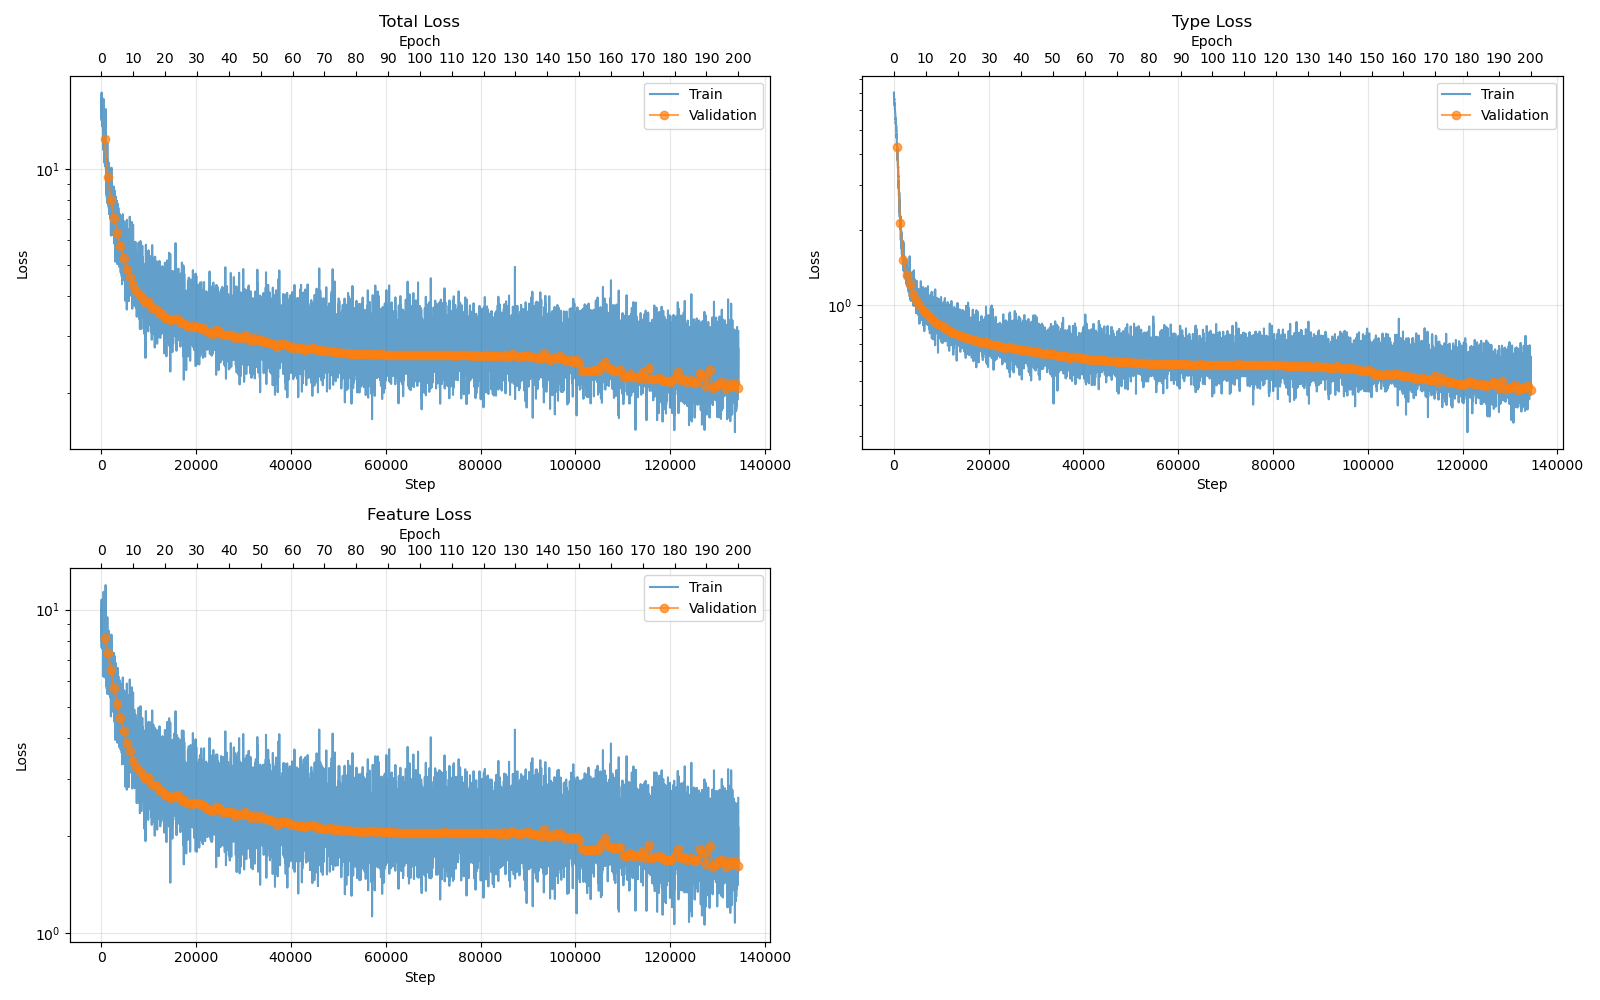

,epoch,step,train_feat_loss,train_loss,train_type_loss,val_feat_loss,val_loss,val_type_loss
0,0,9,8.381445,15.416920,7.035475,NaN,NaN,NaN
1,0,19,8.767518,15.482901,6.715383,NaN,NaN,NaN
2,0,29,10.199943,16.956419,6.756476,NaN,NaN,NaN
3,0,39,9.545688,16.139771,6.594083,NaN,NaN,NaN
4,0,49,10.735763,17.368139,6.632377,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
13635,199,134369,2.131083,2.750446,0.619363,NaN,NaN,NaN
13636,199,134379,1.567012,2.120682,0.553670,NaN,NaN,NaN
13637,199,134389,2.008166,2.446812,0.438647,NaN,NaN,NaN
13638,199,134399,2.616896,3.118083,0.501187,NaN,NaN,NaN


In [121]:
import os
import pandas as pd

def load_and_plot_loss_curves(log_dir):
    """
    Load and plot loss curves from Lightning's CSV logger.
    Plots both loss vs. step and loss vs. epoch, ignoring NaNs.
    """
    # Find the CSV file created by Lightning
    csv_files = [f for f in os.listdir(log_dir) if f.endswith('.csv')]
    
    if not csv_files:
        print(f"No CSV files found in: {log_dir}")
        return None

    csv_path = os.path.join(log_dir, csv_files[0])  # Usually only one CSV file
    df = pd.read_csv(csv_path)
    print(f"Loaded loss curves from: {csv_path}")
    print(f"Columns: {list(df.columns)}")
    print(f"Number of steps about: {len(df)}*{cfg['trainer']['log_every_n_steps']}={len(df)*cfg['trainer']['log_every_n_steps']}")

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    def plot_loss(ax, train_col, val_col, title, logy=False, custom_epoch_ticks=None):
        # Plot train loss (all steps, ignore NaN)
        if train_col in df.columns:
            train_mask = ~df[train_col].isna()
            ax.plot(df['step'][train_mask], df[train_col][train_mask], label='Train', alpha=0.7)
        # Plot val loss (only at epoch end, ignore NaN)
        if val_col in df.columns:
            val_mask = ~df[val_col].isna()
            ax.plot(df['step'][val_mask], df[val_col][val_mask], 'o-', label='Validation', alpha=0.7)
        ax.set_title(title)
        ax.set_xlabel('Step')
        ax.set_ylabel('Loss')
        if logy:
            ax.set_yscale("log")
        ax.legend()
        ax.grid(True, alpha=0.3)
        # Add secondary x-axis for epoch
        if 'epoch' in df.columns:
            ax2 = ax.twiny()
            ax2.set_xlim(ax.get_xlim())
            if custom_epoch_ticks is not None:
                # Map each custom epoch tick to the first step where that epoch appears
                step_ticks = []
                for e in custom_epoch_ticks:
                    steps = df.loc[df['epoch'] == e, 'step']
                    if not steps.empty:
                        step_ticks.append(steps.iloc[0])
                    else:
                        # If epoch not found, interpolate
                        step_ticks.append(np.interp(e, df['epoch'], df['step']))
                ax2.set_xticks(step_ticks)
                ax2.set_xticklabels(custom_epoch_ticks)
            elif val_col in df.columns and val_mask.any():
                epoch_ticks = df['epoch'][val_mask].astype(int)+1
                step_ticks = df['step'][val_mask]
                ax2.set_xticks(step_ticks)
                ax2.set_xticklabels(epoch_ticks)
            else:
                ax2.set_xticks(ax.get_xticks())
                ax2.set_xticklabels(['']*len(ax.get_xticks()))
            ax2.set_xlabel('Epoch')

    logy = True
    custom_epoch_ticks = np.arange(0, 200+1, 10)
    plot_loss(axes[0, 0], 'train_loss', 'val_loss', 'Total Loss', logy, custom_epoch_ticks)
    plot_loss(axes[0, 1], 'train_type_loss', 'val_type_loss', 'Type Loss', logy, custom_epoch_ticks)
    plot_loss(axes[1, 0], 'train_feat_loss', 'val_feat_loss', 'Feature Loss', logy, custom_epoch_ticks)

    # Hide unused subplot if only 3 plots
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

    return df


if False: # set True if it has been resumed training, then loss will be saved to multiple csv files
    dfs = [pd.read_csv(f'GPTlogs/exp_0721/version_{i}/metrics.csv') for i in [0, 1, 2]]
    combined = pd.concat(dfs, ignore_index=True)
    # Sort by step or epoch if needed
    #combined = combined.sort_values(by="step").reset_index(drop=True)
    # Save to new file
    combined.to_csv("GPTlogs/exp_0721/combined.csv", index=False)

load_and_plot_loss_curves("GPTlogs/exp_0721/")

In [109]:
### total class accuracy and feature loss

# --- 1. Prepare test dataset and loader ---
max_seq_len = cfg["trainer"]["max_seq_len"]
batch_size = cfg["trainer"]["batch_size"]
test_data = data[:1000]
test_dataset = ParticleSequenceDataset(test_data, max_seq_len)
test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# --- 2. Set up device and model ---
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

# --- 3. Apply model and compare predictions to targets ---
all_type_losses = []
all_feat_losses = []
all_total_losses = []
all_preds = []
all_targets = []
all_feats_pred = []
all_feats_target = []

with torch.no_grad():
    for batch in test_loader:
        # Move batch to device
        batch = {k: v.to(device) for k, v in batch.items()}
        output = model(batch['encoded_ids'], batch['particle_feats'], batch['padding_mask'])

        # --- Loss calculation (matching training) ---
        particle_types = output['particle_types']  # (batch, seq_len, num_classes)
        particle_feats = output['particle_feats']  # (batch, seq_len, 7)
        targets_types = batch['encoded_ids']       # (batch, seq_len)
        targets_feats = batch['particle_feats']    # (batch, seq_len, 7)
        padding_mask = batch['padding_mask']       # (batch, seq_len)

        # Shift for next-token prediction
        particle_types_shifted = particle_types[:, :-1]
        particle_feats_shifted = particle_feats[:, :-1]
        targets_types_shifted = targets_types[:, 1:]
        targets_feats_shifted = targets_feats[:, 1:]
        padding_mask_shifted = padding_mask[:, 1:]

        # Flatten for loss
        pt_shape = particle_types_shifted.shape
        type_loss = F.cross_entropy(
            particle_types_shifted.reshape(-1, pt_shape[-1]),
            targets_types_shifted.reshape(-1),
            reduction='none'
        )

        feat_loss = F.mse_loss(
            particle_feats_shifted.reshape(-1, 7),
            targets_feats_shifted.reshape(-1, 7),
            reduction='none'
        ).mean(dim=1)

        # Mask out padding
        padding_mask_flat = padding_mask_shifted.reshape(-1)
        valid_mask = ~padding_mask_flat
        type_loss = type_loss * valid_mask.float()
        feat_loss = feat_loss * valid_mask.float()
        num_valid = valid_mask.sum()
        type_loss = type_loss.sum() / max(num_valid, 1)
        feat_loss = feat_loss.sum() / max(num_valid, 1)
        total_loss = type_loss + feat_loss

        all_type_losses.append(type_loss.item())
        all_feat_losses.append(feat_loss.item())
        all_total_losses.append(total_loss.item())

        # --- For accuracy and inspection ---
        # Get predictions for valid positions only
        preds = torch.argmax(particle_types_shifted, dim=-1)  # [batch, seq_len-1]
        all_preds.append(preds.cpu())
        all_targets.append(targets_types_shifted.cpu())
        all_feats_pred.append(particle_feats_shifted.cpu())
        all_feats_target.append(targets_feats_shifted.cpu())

# --- 4. Concatenate all predictions and targets ---
all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)
all_feats_pred = torch.cat(all_feats_pred, dim=0)
all_feats_target = torch.cat(all_feats_target, dim=0)

# --- 5. Compute accuracy, ignoring PAD tokens ---
mask = all_targets != 0  # PAD_TOKEN = 0
accuracy = (all_preds[mask] == all_targets[mask]).float().mean().item()
print(f"Test accuracy: {accuracy:.4f}")

# --- 6. Compute feature MSE, matching training ---
mean_feat_loss = sum(all_feat_losses) / len(all_feat_losses)
print(f"Feature MSE (matching training): {mean_feat_loss:.6f}")

# --- 7. Print a few predictions vs targets for inspection ---
ievt = 0
print(f"\nEvent {ievt}:")
print("  Target (types):     ", all_targets[ievt].tolist())
print("  Prediction (types): ", all_preds[ievt].tolist())
print("  Target (features):")
target_feats_shifted = all_feats_target[ievt][1:]
pred_feats_shifted = all_feats_pred[ievt][:-1]
mask_shifted = mask[ievt][1:]
valid_idx = mask_shifted.nonzero(as_tuple=True)[0]
print(target_feats_shifted[valid_idx].numpy())
print("  Prediction (features):")
print(pred_feats_shifted[valid_idx].numpy())

### Start prepare_sequence_for_training: 1000 raw event sequences
Converting to tensors...
### Complete prepare_sequence_for_training: 1410 sequences generated
Test accuracy: 0.8303
Feature MSE (matching training): 1.416654

Event 0:
  Target (types):      [1153, 1024, 1025, 1153, 1024, 1025, 1153, 1024, 1025, 1153, 1024, 1025, 1153, 1024, 1025, 1153, 1024, 1025, 1025, 1153, 1024, 1025, 1025, 1153, 1024, 1025, 1025, 1153, 1024, 1025, 1025, 1153, 1024, 1025, 1025, 1153, 1024, 1025, 1025, 1153, 1024, 1025, 1025, 1153, 1024, 1025, 1025, 1153, 1024, 1025, 1025, 1153, 1024, 1025, 1153, 1025, 1153, 1024, 1025, 1153, 1025, 1153, 1024, 1025, 1153, 1025, 1153, 1024, 1025, 1153, 1025, 1153, 1024, 1025, 1153, 1025, 1153, 1024, 1025, 1153, 1025, 1153, 1024, 1025, 1153, 1025, 1153, 1024, 1025, 1153, 1025, 1153, 1024, 1025, 1153, 1025, 1025, 1153, 1024, 1025, 1153, 1025, 1025, 1153, 1024, 1025, 1153, 1025, 1025, 1153, 1024, 1025, 1153, 1025, 1025, 1153, 1024, 1025, 1153, 1025, 1025, 1153, 1024, 1025

In [50]:
### test the class match for a specific event
def count_position_matches(
    list1, list2, ignore_values=None, consider_values=None
):
    """
    Counts how many elements match in the same position in two lists,
    with options to ignore and/or only consider certain values.

    - If ignore_values is provided, positions where either value is in ignore_values are skipped.
    - If consider_values is provided, only positions where both values are in consider_values are considered (after ignoring).
    - Returns a tuple: (number of matches, total positions considered)
    """
    ignore_set = set(ignore_values) if ignore_values is not None else set()
    consider_set = set(consider_values) if consider_values is not None else None

    filtered = []
    for a, b in zip(list1, list2):
        if a in ignore_set or b in ignore_set:
            continue
        if consider_set is not None and (a not in consider_set or b not in consider_set):
            continue
        filtered.append((a, b))

    matches = sum(1 for a, b in filtered if a == b)
    total_considered = len(filtered)
    return matches, total_considered

# Example usage:
ievt_test
list1 = all_targets[ievt_test].tolist()
list2 = all_preds[ievt_test].tolist()
matches, total = count_position_matches(list1, list2, ignore_values=[0], consider_values=[1025])
print(f"Number of matches in position: {matches} out of {total}")

Number of matches in position: 421 out of 421


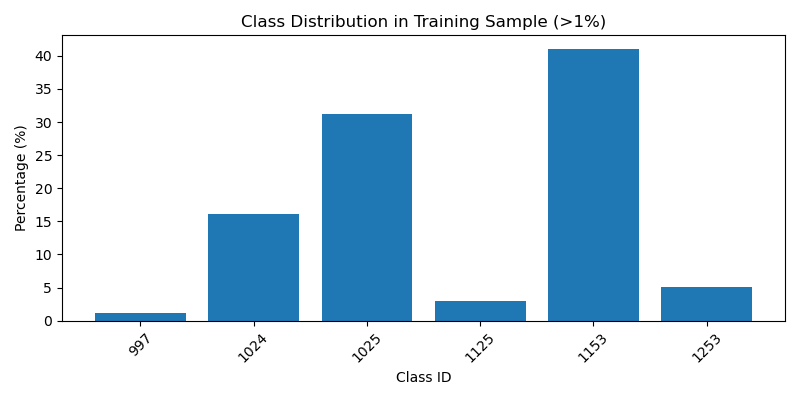

/tmp/ipykernel_20746/4114986024.py:54: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(7, 6))


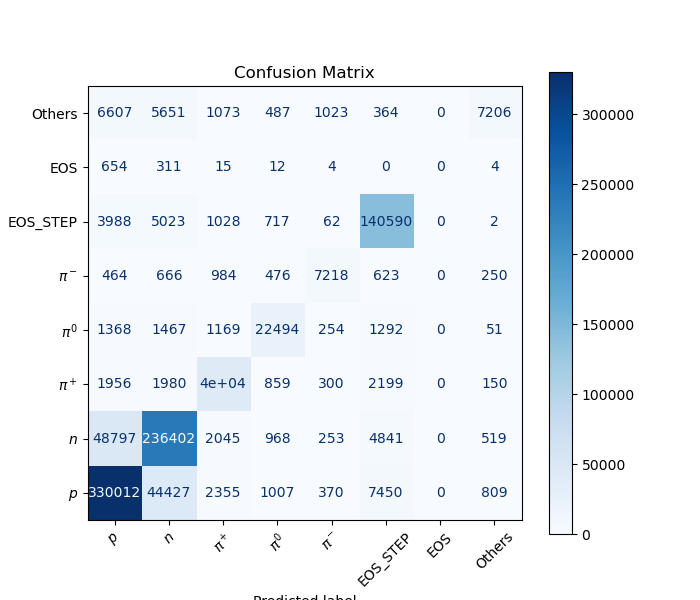

In [122]:
### show disbutions of true class of the test sample 
flat_train_targets = all_targets[all_targets != PAD_TOKEN].flatten()

# Count occurrences
unique, counts = np.unique(flat_train_targets, return_counts=True)
total = counts.sum()
percentages = counts / total

# Filter for classes exceeding 1%
mask = percentages > 0.01
filtered_classes = unique[mask]
filtered_percentages = percentages[mask]

# Plot
plt.figure(figsize=(8, 4))
plt.bar([str(c) for c in filtered_classes], filtered_percentages * 100)
plt.ylabel("Percentage (%)")
plt.xlabel("Class ID")
plt.title("Class Distribution in Training Sample (>1%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#print("gibuuID, charge, _", decode_id(1153))

### draw confusion matrix for major classes (given all previous true particles, compare the predicted the true particle at this position)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Define your main classes and the "others" label
main_classes = [1153, 1025, 1253, 1125, 997, EOS_STEP_TOKEN, EOS_TOKEN] #, PAD_TOKEN
name_classes = [r"$p$", r"$n$", r"$\pi^+$", r"$\pi^0$", r"$\pi^-$", "EOS_STEP", "EOS"] #, "PAD"
others_label = 9999  # Use a value not in your classes

# 2. Flatten predictions and targets, mask out PAD tokens
mask = all_targets != PAD_TOKEN
y_true = all_targets[mask].cpu().numpy().flatten()
y_pred = all_preds[mask].cpu().numpy().flatten()

# 3. Map to main classes or "others"
def map_to_main_or_others(arr):
    return np.array([x if x in main_classes else others_label for x in arr])

y_true_mapped = map_to_main_or_others(y_true)
y_pred_mapped = map_to_main_or_others(y_pred)

# 4. Prepare labels for confusion matrix
labels = main_classes + [others_label]
label_names = name_classes + ['Others']

# 5. Compute confusion matrix
cm = confusion_matrix(y_true_mapped, y_pred_mapped, labels=labels)

# 6. Plot confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.gca().invert_yaxis() # Origin at lower left
plt.title("Confusion Matrix")
plt.show()

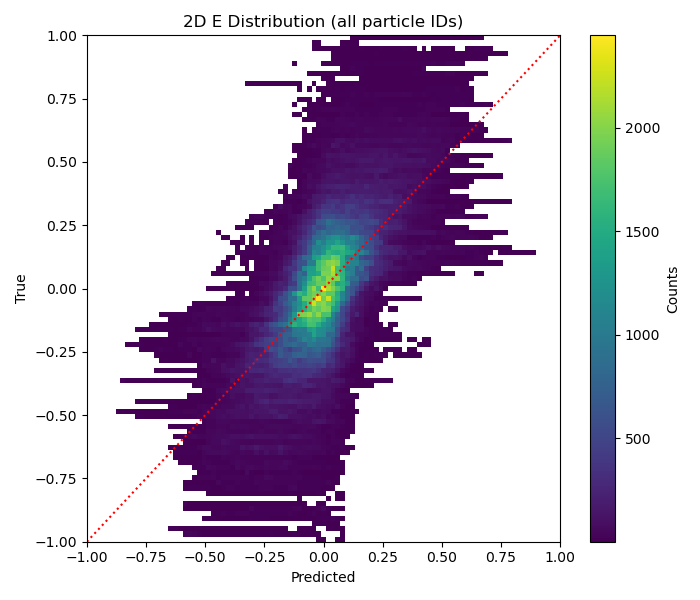

In [123]:
def plot_2d_feature_distribution(
    all_feats_pred, all_feats_target, all_preds, all_targets,
    feature_index, matched=False, particle_id=None, bins=None, vmin=None, vmax=None, 
    xlabel="Predicted", ylabel="True", title="2D Feature Distribution"
):
    """
    Draws a 2D histogram of a feature: predicted vs. true.
    
    Parameters:
    -----------
    all_feats_pred: tensor/array, shape [N, seq_len, n_feat]
    all_feats_target: tensor/array, shape [N, seq_len, n_feat]
    all_preds: tensor/array, shape [N, seq_len]
    all_targets: tensor/array, shape [N, seq_len]
    feature_index: int, which feature to plot ([x,y,z,E,Px,Py,Pz] e.g., 3 for E)
    matched: bool, if True, only plot where predicted ID == true ID
    particle_id: int, list or None, if set, only plot for the provided IDs
    bins: list, bin edges for the histogram
    vmin, vmax: for color scale
    xlabel, ylabel, title: plot labels
    """
    # Flatten everything
    pred_ids = all_preds.flatten()
    true_ids = all_targets.flatten()
    pred_feat = all_feats_pred[..., feature_index].flatten()
    true_feat = all_feats_target[..., feature_index].flatten()
    
    # Mask for non-particle tokens
    mask = (true_ids != PAD_TOKEN) & (true_ids != EOS_STEP_TOKEN) & (true_ids != EOS_TOKEN)
    if matched:
        mask = mask & (pred_ids == true_ids)
    if particle_id is not None:
        if type(particle_id) is int:
            particle_id = [particle_id]
        mask = mask & np.isin(true_ids, particle_id)
    
    # Apply mask
    mask = mask.bool()
    x = pred_feat[mask]
    y = true_feat[mask]

    # Set the same range for both axes
    if bins is None:
        min_val = min(x.min(), y.min())
        max_val = max(x.max(), y.max())
        bins = np.linspace(min_val, max_val, 101)
    xmin = bins[0]
    xmax = bins[-1]

    # Set up colormap with white for empty bins
    cmap = plt.get_cmap('viridis').copy()
    cmap.set_bad('white')
    
    plt.figure(figsize=(7, 6))
    plt.hist2d(x, y, bins=bins, cmap=cmap, cmin=1, vmin=vmin, vmax=vmax)
    plt.plot([xmin, xmax], [xmin, xmax], "r:") # reference line
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xlim(xmin, xmax)
    plt.ylim(xmin, xmax)
    plt.title(title + (f" (ID={particle_id})" if particle_id is not None else " (all particle IDs)"))
    plt.colorbar(label="Counts")
    plt.tight_layout()
    plt.show()

plot_2d_feature_distribution(
    all_feats_pred, all_feats_target, all_preds, all_targets,
    feature_index=4, matched=True, particle_id=None, bins=np.linspace(-1, 1, 100),
    xlabel="Predicted", ylabel="True", title="2D E Distribution"
)

### Generating new events

In [85]:
### generate a new event sequence
import torch
import gc

# --- 1. Prepare initial context (first 10 time steps of event 0) ---
ievt = 0
event_tokens = all_targets[ievt]         # [seq_len]
event_feats = all_feats_target[ievt]     # [seq_len, n_feat]

time_step_indices = (event_tokens == EOS_STEP_TOKEN).nonzero(as_tuple=True)[0]
if len(time_step_indices) < 10:
    raise ValueError("Event has fewer than 10 time steps!")
cutoff_idx = time_step_indices[9] + 1  # Include the EOS_STEP of the 10th step

tokens_in = event_tokens[:cutoff_idx].unsqueeze(0).to(device)  # [1, seq_init]
feats_in = event_feats[:cutoff_idx].unsqueeze(0).to(device)    # [1, seq_init, n_feat]
mask_in = torch.zeros_like(tokens_in, dtype=torch.bool).to(device)  # [1, seq_init]

# --- Print the first 10 time steps (input context) ---
cur_time_step = 0
cur_step_tokens = []
cur_step_feats = []
output_sequence = []
print("First 10 time steps (input context):")
for i in range(cutoff_idx):
    token_val = event_tokens[i].item()
    feat_val = event_feats[i].cpu().detach().numpy()
    if token_val == EOS_STEP_TOKEN:
        # Print/Process the finished time step
        print(f"\nInput time step {cur_time_step}:")
        for t, f in zip(cur_step_tokens, cur_step_feats):
            gibuuID, charge, _ = decode_id(t)
            x, y, z, E, Px, Py, Pz = f
            row = [cur_time_step, gibuuID, charge, x, y, z, E, Px, Py, Pz]
            print(row)
            output_sequence.append(row)
        cur_time_step += 1
        cur_step_tokens = []
        cur_step_feats = []
    else:
        cur_step_tokens.append(token_val)
        cur_step_feats.append(feat_val)

# --- 2. Autoregressive generation, print after each time step ---
model.eval()
max_gen_len = 500  # or as needed

print(f"\nStarting generation from time step {cur_time_step}...")

for step in range(max_gen_len):
    # Forward pass
    output = model(tokens_in, feats_in, mask_in)
    logits = output['particle_types']
    feats_pred = output['particle_feats']

    # Get next token and features (last position)
    next_token = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)  # [1, 1]
    next_feat = feats_pred[:, -1:, :]  # [1, 1, n_feat]

    # Append to the sequence
    tokens_in = torch.cat([tokens_in, next_token], dim=1)
    feats_in = torch.cat([feats_in, next_feat], dim=1)
    mask_in = torch.cat([mask_in, torch.zeros_like(next_token, dtype=torch.bool)], dim=1)

    token_val = next_token.item()
    feat_val = next_feat[0, 0].cpu().detach().numpy()

    # Clear intermediate tensors to save memory
    del output, logits, feats_pred, next_token, next_feat
    if device == "cuda":
        torch.cuda.empty_cache()

    if token_val == EOS_TOKEN:
        print("EOS_TOKEN generated. Stopping generation.")
        break
    elif token_val == EOS_STEP_TOKEN:
        # Print/Process the finished time step
        print(f"\nGenerated time step {cur_time_step}:")
        for t, f in zip(cur_step_tokens, cur_step_feats):
            gibuuID, charge, _ = decode_id(t)
            x, y, z, E, Px, Py, Pz = f
            row = [cur_time_step, gibuuID, charge, x, y, z, E, Px, Py, Pz]
            print(row)
            output_sequence.append(row)
        cur_time_step += 1
        cur_step_tokens = []
        cur_step_feats = []
        gc.collect()
        if device == "cuda":
            torch.cuda.empty_cache()
    else:
        cur_step_tokens.append(token_val)
        cur_step_feats.append(feat_val)

# If there are any remaining particles in the last time step, print them
if cur_step_tokens:
    print(f"\nGenerated time step {cur_time_step}:")
    for t, f in zip(cur_step_tokens, cur_step_feats):
        gibuuID, charge, _ = decode_id(t)
        x, y, z, E, Px, Py, Pz = f
        row = [cur_time_step, gibuuID, charge, x, y, z, E, Px, Py, Pz]
        print(row)
        output_sequence.append(row)

print(f"\nGeneration completed. Total time steps: {cur_time_step}")
print(f"Total particles generated: {len(output_sequence)}")

# --- Robust memory cleanup ---
del tokens_in, feats_in, mask_in
del cur_step_tokens, cur_step_feats
del event_tokens, event_feats
gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()
model.to("cpu")
gc.collect()
torch.cuda.empty_cache()
model.to(device);

First 10 time steps (input context):

Input time step 0:
[0, 1, 1, 2.0931642, -2.7057195, 0.2997023, 1.0682777, -0.05910364, -0.32833585, 0.4430661]

Input time step 1:
[1, 1, 0, 2.0289752, -2.6069424, 0.434838, 2.0826612, -0.66438544, 1.0225568, 1.4006779]
[1, 1, 1, 2.0810835, -2.7724397, 0.3898245, 1.0683177, -0.05971688, -0.32756975, 0.44298974]

Input time step 2:
[2, 1, 0, 1.9648871, -2.5082874, 0.5701417, 2.08265, -0.6626641, 1.0203352, 1.4011819]
[2, 1, 1, 2.0689206, -2.8387108, 0.47955558, 1.0683334, -0.06039572, -0.32661495, 0.4428391]

Input time step 3:
[3, 1, 0, 1.9009141, -2.4097602, 0.7056208, 2.0826898, -0.66086596, 1.0180112, 1.4017822]
[3, 1, 1, 2.0566592, -2.90453, 0.5689204, 1.0682545, -0.061162192, -0.32545638, 0.44262993]

Input time step 4:
[4, 1, 0, 1.8370599, -2.3113794, 0.8412814, 2.0826862, -0.6590293, 1.0156419, 1.4025491]
[4, 1, 1, 2.0442805, -2.9698322, 0.65788585, 1.0682341, -0.062045813, -0.32409248, 0.44238874]

Input time step 5:
[5, 1, 0, 1.7733376, -2

In [86]:
import numpy as np

def extract_visualization_lists_from_output_sequence(output_sequence, gibuu_charge_to_pdg):
    """
    Given output_sequence and a lookup table, return positions_list, momenta_list, pdg_codes_list, timestep_list.
    
    Parameters:
    -----------
    output_sequence: list of [time_step, gibuuID, charge, x, y, z, E, Px, Py, Pz]
    gibuu_charge_to_pdg: dict mapping (gibuuID, charge) -> PDG code
    
    Returns:
    --------
    positions_list: list of np.ndarray, each shape (n_particles, 3)
    momenta_list: list of np.ndarray, each shape (n_particles, 3)
    pdg_codes_list: list of np.ndarray, each shape (n_particles,)
    timestep_list: list of int
    """
    positions_list = []
    momenta_list = []
    pdg_codes_list = []
    timestep_list = []

    current_timestep = None
    cur_positions = []
    cur_momenta = []
    cur_pdgs = []

    for row in output_sequence:
        time_step, gibuuID, charge, x, y, z, E, Px, Py, Pz = row
        if current_timestep is None:
            current_timestep = time_step

        if time_step != current_timestep:
            # Save the previous time step's data
            if cur_positions:
                positions_list.append(np.array(cur_positions))
                momenta_list.append(np.array(cur_momenta))
                pdg_codes_list.append(np.array(cur_pdgs))
                timestep_list.append(current_timestep)
            # Start new time step
            current_timestep = time_step
            cur_positions = []
            cur_momenta = []
            cur_pdgs = []

        # Lookup PDG code
        pdg = gibuu_charge_to_pdg.get((gibuuID, charge), 0)  # 0 if not found
        cur_positions.append([x, y, z])
        cur_momenta.append([Px, Py, Pz])
        cur_pdgs.append(pdg)

    # Don't forget the last time step
    if cur_positions:
        positions_list.append(np.array(cur_positions))
        momenta_list.append(np.array(cur_momenta))
        pdg_codes_list.append(np.array(cur_pdgs))
        timestep_list.append(current_timestep)

    return positions_list, momenta_list, pdg_codes_list, timestep_list


gibuu_charge_to_pdg = {(1, 1): 2212, (1, 0): 2112, (101, 1): 211, (101, 0): 111, (101, -1): -211,}

positions_list, momenta_list, PDG_list, timestep_list = extract_visualization_lists_from_output_sequence(
    output_sequence, gibuu_charge_to_pdg
)

IntSlider(value=0, description='Time Step', max=60)

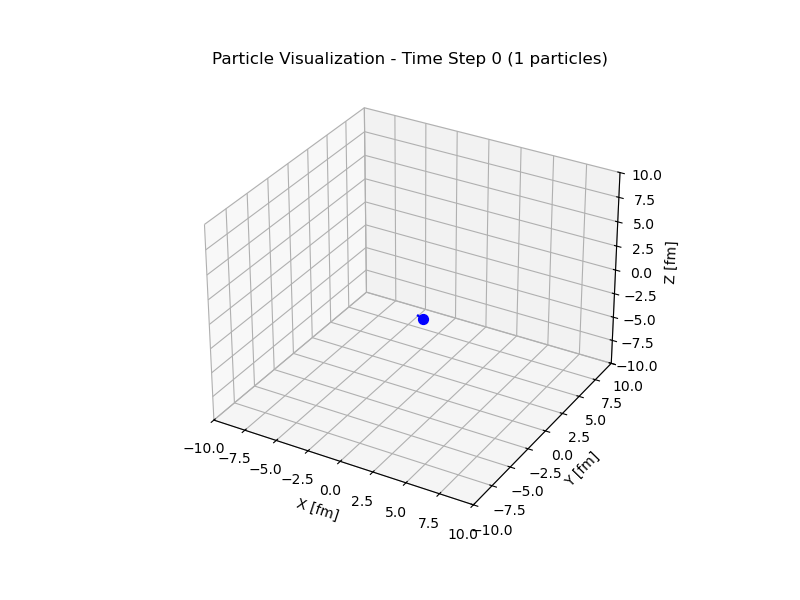

In [124]:
%matplotlib widget
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from ipywidgets import widgets
from IPython.display import display

pdg_color_map = {
    12: 'gray',         # electron neutrino
    14: 'gray',         # muon neutrino
    16: 'gray',         # tau neutrino
    11: 'red',          # electron
    -11: 'red',         # positron
    13: 'magenta',      # muon
    -13: 'magenta',     # muon+
    15: 'violet',       # tau
    -15: 'violet',      # tau+
    2212: 'blue',       # proton
    2112: 'cyan',       # neutron
    211: 'orange',      # pi+
    -211: 'darkorange', # pi-
    111: 'gold',        # pi0
    321: 'green',       # K+
    -321: 'darkgreen',  # K-
    311: 'lime',        # K0
    22: 'yellow',       # photon
}

def visualize_particles_with_slider( # visualize particles at each time step
    positions_list, momenta_list, pdg_codes_list, 
    timestep_list=None,
    xlim=None, ylim=None, zlim=None
):
    n_steps = len(positions_list)

    # Create figure and axis once
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    def plot_frame(step):
        ax.clear()
        if False: # Draw a sphere of radius centered at the origin (adding it the image update may become slower)
            radius = 5
            u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
            sphere_x = radius * np.cos(u) * np.sin(v)
            sphere_y = radius * np.sin(u) * np.sin(v)
            sphere_z = radius * np.cos(v)
            ax.plot_wireframe(sphere_x, sphere_y, sphere_z, color='gray', alpha=0.2, linewidth=0.5)
            ax.plot_surface(sphere_x, sphere_y, sphere_z, color='gray', alpha=0.05, linewidth=0, shade=True)
        
        positions = np.asarray(positions_list[step])
        momenta = np.asarray(momenta_list[step])
        pdg_codes = np.asarray(pdg_codes_list[step])

        for i in range(len(positions)):
            x, y, z = positions[i]
            px, py, pz = momenta[i]
            color = pdg_color_map.get(pdg_codes[i], 'black')

            # Draw momentum vector (arrow)
            ax.quiver(x, y, z, px, py, pz, length=1, normalize=True, 
                      arrow_length_ratio=0.1, color=color)
            # Draw particle position (marker)
            ax.scatter(x, y, z, color=color, marker='o', s=50)

        ax.set_xlabel('X [fm]')
        ax.set_ylabel('Y [fm]')
        ax.set_zlabel('Z [fm]')
        if timestep_list:
            ax.set_title(f'Particle Visualization - Time Step {timestep_list[step]} ({len(pdg_codes)} particles)')
        else:
            ax.set_title(f'Particle Visualization - Time Step {step} ({len(pdg_codes)} particles)')


        # Apply fixed limits if provided
        if xlim:
            ax.set_xlim(*xlim)
        if ylim:
            ax.set_ylim(*ylim)
        if zlim:
            ax.set_zlim(*zlim)

        fig.canvas.draw_idle()  # Efficient redraw

    # Create and display the slider
    slider = widgets.IntSlider(
        min=0, max=n_steps - 1, step=1, value=0, description='Time Step'
    )

    def on_slider_change(change):
        if change['name'] == 'value':
            plot_frame(change['new'])

    slider.observe(on_slider_change)
    display(slider)

    # Initial plot
    plot_frame(0)

visualize_particles_with_slider(positions_list, momenta_list, PDG_list, timestep_list, xlim=[-10,10], ylim=[-10,10], zlim=[-10,10])